# ENSO Ensemble Analysis Template (CESM / ERA5)

This notebook demonstrates a clean workflow for analyzing ENSO diagnostics using:
- xarray
- ensemble dimensions
- vectorized diagnostics

Key ideas:
1. Load ensemble members into a `member` dimension
2. Compute ENSO diagnostics per member
3. Average diagnostics across ensemble members
4. Use vectorized xarray operations (`groupby`, `where`, etc.)


## Imports

In [1]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt


## Utility: Build ensemble member names

Automatically generates `.001 .002 .003` etc.

In [2]:
def build_members(case_base, n_members):
    return [f"{case_base}.{i:03d}" for i in range(1, n_members+1)]

## Dataset loader

Handles CESM1 / CESM2 differences.

In [3]:
def load_member(case, case_type, var):
    
    if case_type == "cesm2":
        root = "/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1/"
    
    elif case_type == "cesm1":
        root = "/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/monthly/"

    files = glob.glob(f"{root}/{var}/{case}*.nc")
    print(files)
    ds = xr.open_mfdataset(files, combine="by_coords", parallel=True)

    return ds[var]

## Load ensemble into a `member` dimension

In [4]:
def load_ensemble(case_base, n_members, case_type, var):

    members = build_members(case_base, n_members)

    datasets = []

    for i, mem in enumerate(members):
        print("Loading", mem)

        da = load_member(mem, case_type, var)

        da = da.expand_dims(member=[i])

        datasets.append(da)

    return xr.concat(datasets, dim="member")

## ENSO Niño3.4 index

In [5]:
def nino34_index(da):

    region = da.sel(lat=slice(-5,5), lon=slice(190,240))

    ts = region.mean(("lat","lon"))

    clim = ts.groupby("time.month").mean("time")

    anom = ts.groupby("time.month") - clim

    return anom

## ENSO composite calculation

In [6]:
def enso_composite(field, nino_index, threshold=1):

    elnino = field.where(nino_index > threshold)

    composite = elnino.groupby("time.season").mean("time")

    return composite

## Example workflow

Load CESM2 ensemble SST.

In [8]:
ts = load_ensemble(
    "b.e21.BHISTsmbb.f09_g17.LE2-1011",
    1,
    "cesm2",
    "TS"
)

Loading b.e21.BHISTsmbb.f09_g17.LE2-1011.001
['/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1//TS/b.e21.BHISTsmbb.f09_g17.LE2-1011.001.cam.h0.TS.185001-185912.nc', '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1//TS/b.e21.BHISTsmbb.f09_g17.LE2-1011.001.cam.h0.TS.186001-186912.nc', '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1//TS/b.e21.BHISTsmbb.f09_g17.LE2-1011.001.cam.h0.TS.193001-193912.nc', '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1//TS/b.e21.BHISTsmbb.f09_g17.LE2-1011.001.cam.h0.TS.201001-201412.nc', '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1//TS/b.e21.BHISTsmbb.f09_g17.LE2-1011.001.cam.h0.TS.197001-197912.nc', '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1//TS/b.e21.BHISTsmbb.f09_g17.LE2-1011.001.cam.h0.TS.198001-198912.nc', '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1//TS/b.e21.BHISTsmbb.f09_g17.LE2-1011.

/glade/derecho/scratch/rneale/tmp/ipykernel_55140/3752735906.py:11: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords", parallel=True)


## Compute ENSO index

In [9]:
nino = nino34_index(ts)

## Compute composites for all members simultaneously

In [10]:
elnino_comp = enso_composite(ts, nino)

## Ensemble mean composite

In [11]:
elnino_mean = elnino_comp.mean("member")

## Plot DJF composite

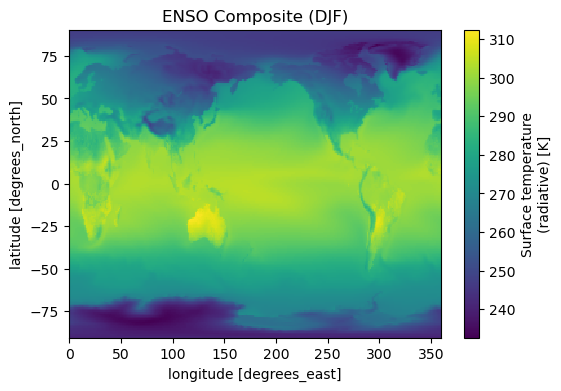

In [12]:
fig, ax = plt.subplots(figsize=(6,4))

elnino_mean.sel(season="DJF").plot(ax=ax)

ax.set_title("ENSO Composite (DJF)")

plt.show()